<a href="https://colab.research.google.com/github/KorolevskiiKorol/SUAI-Data_Analytics_lern/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Data_analytics_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторная работа 2
по дисциплине «Прикладная теория вероятностей и математическая статистика»

Описательная статистика и визуализация

Цели и задачи работы
Цель работы: научиться проводить первичный разведочный анализ данных (EDA) с
использованием инструментов Python, выявлять аномалии в IT-метриках и формулировать
гипотезы о состоянии системы.
Задачи:
1. Освоить базовые методы Pandas для описания DataFrame.
2. Научиться визуализировать распределения числовых метрик.
3. Научиться выявлять выбросы (аномалии) и пропуски в данных.
4. Интерпретировать взаимосвязи между метриками с помощью графиков.



Для лабораторной работы я использовал датасет с платформы kaggle:  ["Набор данных о производительности и поведении студентов (20K)"](https://www.kaggle.com/datasets/algozee/student-productivity-and-behavior-dataset-20k?resource=download)

Набор данных содержит 20,000 структурированных записей студентов, которые собирают информацию, связанную с учебными привычками, цифровыми моделями использования, показателями хорошего самочувствия, показателями производительности и академическими результатами.

# Этап 1. Загрузка и первичное исследование (EDA Start)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/student_productivity_distraction_dataset_20000.csv')

df

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


Подсчиатем количество колонок и строк с помощью метода `shape`.

In [ ]:
print(f"Столбцов: {df.shape[1]}\nСтрок: {df.shape[0]}")

Столбцов: 18
Строк: 20000


Количество строк и столбцов соответсвует минимальным требованиям ЛБ. Далее определяем какие типы данных содержат колонки методом `info()`

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

Как видим, в датасете содержится 20 000 записей и 18 колонок, при этом пропущенных значений нет — во всех столбцах по
20 000 non-null значений.

По типам данных:

8 колонок с целочисленными значениями (int64) — это student_id, age, breaks_per_day, coffee_intake_mg, exercise_minutes, assignments_completed, stress_level, focus_score.
Здесь представлены идентификатор студента и различные количественные показатели (возраст, количество перерывов, уровень стресса и т.д.).

9 колонок со значениями с плавающей точкой (float64) — это study_hours_per_day, sleep_hours, phone_usage_hours, social_media_hours, youtube_hours, gaming_hours, attendance_percentage, final_grade, productivity_score.
Они отражают числовые измеряемые показатели (часы активности, процент посещаемости, итоговая оценка, уровень продуктивности).

1 категориальная колонка (object) — gender, которая содержит текстовые значения (например, мужской или женский пол).

Далее получим базовую статистику для числовых колонок используz метод `describe()`

In [ ]:
df.describe(include='all')

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
unique,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,9640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,10000.500000,23.00745,NaN,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,NaN,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,NaN,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,NaN,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,NaN,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,NaN,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500


В базовой статистике не наблюдается подозрительных отклоний/выбросов. Все значения находятся в логических пределах.

# Этап 2. Предобработка данных (Data Cleaning)

Выполним полный цикл обработки данных: Проверим таблицу на наличие пропусков.

In [ ]:
df.isna().mean()

,0
student_id,0.0
age,0.0
gender,0.0
study_hours_per_day,0.0
sleep_hours,0.0
phone_usage_hours,0.0
social_media_hours,0.0
youtube_hours,0.0
gaming_hours,0.0
breaks_per_day,0.0


Видим, что пропусков в таблице нет. Заменим тип столбца gender на bool и преобразуем значения - сделаем Male `True`, a Female `False`

In [ ]:
df["gender"] = df["gender"].replace("Other", "Male").map({"Male": True, "Female": False})
df

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,False,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,True,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,False,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,False,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,True,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,False,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,True,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,True,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,False,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


Далее проведем проверку таблицы на наличие дубликатов.

In [ ]:
print(df.duplicated().sum())

0


Видим, что дублирующися строк нет. Переходим к обработке выбросов через matplotlib.

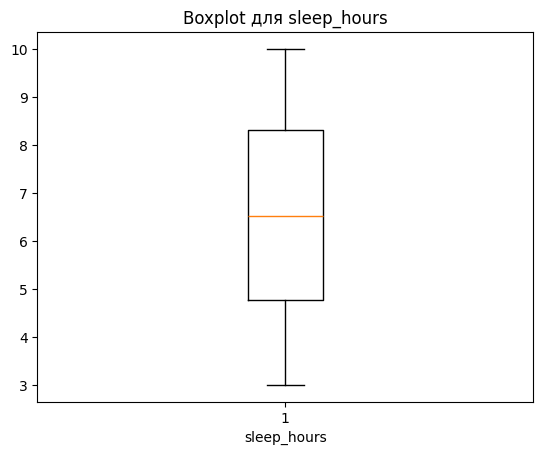

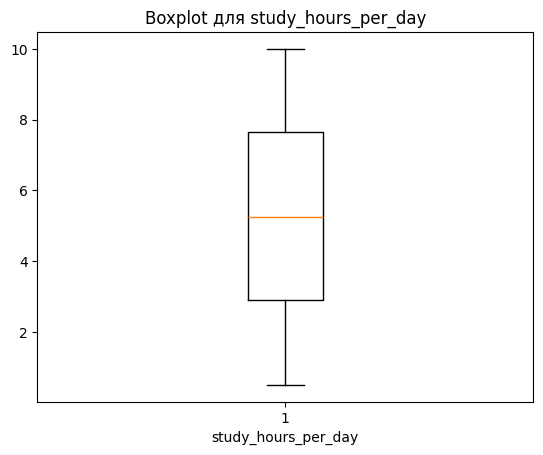

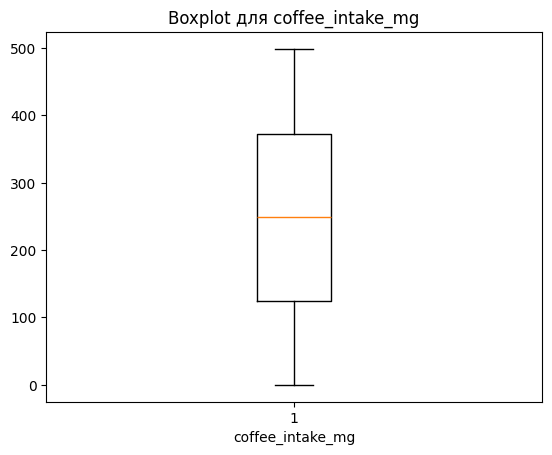

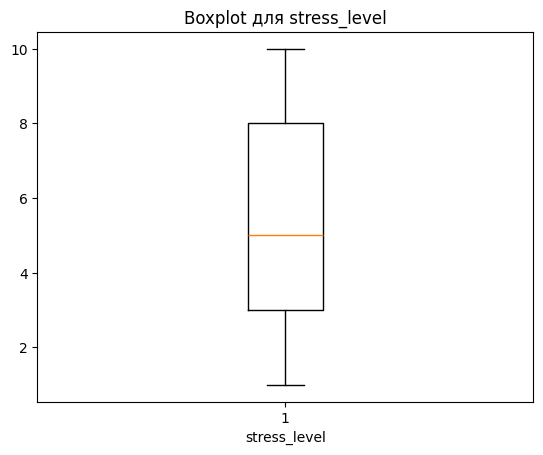

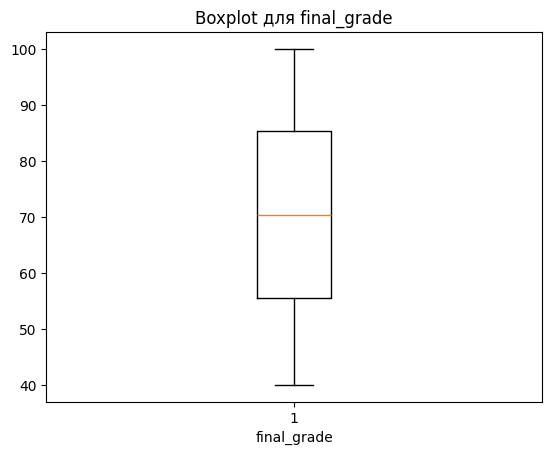

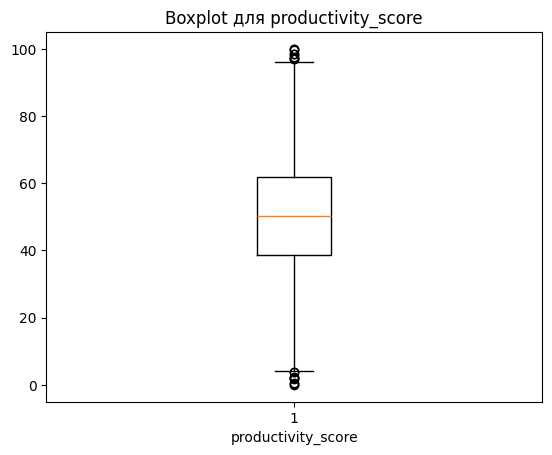

In [ ]:
import matplotlib.pyplot as plt

columns = [
    "sleep_hours",
    "study_hours_per_day",
    "coffee_intake_mg",
    "stress_level",
    "final_grade",
    "productivity_score"
]

for col in columns:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot для {col}")
    plt.xlabel(col)
    plt.show()

По boxplot переменной productivity_score наблюдаются выбросы как в нижней, так и в верхней части распределения. Значения выходят за пределы межквартильного размаха. Но так как значения варьируются от 0 до 100, то мы не будем считать их выбросами. Остальные значения соответсвуют норме.

# Этап 3. Описательная статистика

Сгруппируем данные по категариальному признаку. Но так как категориальный признак всего один, то попробуем скомбинировать по числовым. Для каждой группы рассчитаем среднее, медиану, стандартное отклонение по целевой метрике.

In [ ]:
df.groupby("gender")["productivity_score"].agg(["mean", "median", "std"])

,mean,median,std
gender,,,
False,50.103528,50.215,16.005919
True,50.251965,50.270,16.161883


In [ ]:
df.groupby("stress_level")["productivity_score"].agg(["mean", "median", "std"])

,mean,median,std
stress_level,,,
1,54.920355,54.540,15.523165
2,54.226298,54.100,15.652046
3,53.304167,53.225,15.498122
4,51.320321,51.520,15.796765
5,50.974854,50.810,15.938913
6,49.283372,49.785,15.623973
7,48.572312,48.500,15.972854
8,47.384403,47.180,15.716100
9,46.463418,46.350,15.976765


Как мы видим гендерный признак не влияет на продуктивность, однако чем больше уровень стресса, тем меньше продуктивность у студентов. Расчитаем коэффициенты асимметрии и эксцесса

In [ ]:
def skew_kurtosis_analysis(df, columns):
    import pandas as pd

    results = df[columns].agg(["skew", "kurtosis"]).T
    results.rename(columns={
        "skew": "asymmetry (skew)",
        "kurtosis": "kurtosis (excess)"
    }, inplace=True)

    return results

    columns = [
    "sleep_hours",
    "study_hours_per_day",
    "coffee_intake_mg",
    "final_grade",
    "productivity_score"
]

skew_kurtosis_analysis(df, columns)

,asymmetry (skew),kurtosis (excess)
sleep_hours,-0.005947,-1.207811
study_hours_per_day,0.006814,-1.198193
coffee_intake_mg,0.001642,-1.198016
stress_level,0.003067,-1.228379
final_grade,-0.018430,-1.193742
productivity_score,-0.012525,-0.428976


Распределения практически симметричные
Явного «хвоста» ни слева, ни справа нет
Данные близки к нормальному распределению

Так как *skew* < 0.5 для всех переменных — асимметрия отсутствует.


Проведем корреляционный анализ. Основной задачей такого анализа является выяснение связей между различными переменными.

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64", "bool"])

corr_matrix = numeric_df.corr(method="pearson")

corr_matrix

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
student_id,1.000000,-0.004398,-0.008049,0.010596,-0.012768,-0.001470,0.000120,-0.004159,0.005024,0.003951,0.004558,-0.002843,0.003091,0.021324,0.006859,0.015330,0.007043,0.012579
age,-0.004398,1.000000,0.000395,-0.005029,0.010650,0.009090,0.003258,0.013934,0.001777,-0.006727,0.006629,0.001646,-0.003458,-0.006531,-0.002612,-0.004130,-0.000857,-0.005423
gender,-0.008049,0.000395,1.000000,0.003828,0.005372,-0.006300,-0.000244,-0.000101,0.002753,0.007119,-0.001466,0.001388,0.001606,-0.005131,-0.007394,-0.006549,-0.005776,0.004611
study_hours_per_day,0.010596,-0.005029,0.003828,1.000000,0.001670,0.011539,0.004888,-0.002238,-0.002104,-0.010371,0.004788,0.004380,0.005643,-0.008083,0.001781,0.004536,-0.012208,0.732777
sleep_hours,-0.012768,0.010650,0.005372,0.001670,1.000000,0.000016,-0.005939,0.004920,-0.003666,-0.000677,0.000882,0.006526,0.000944,0.003433,0.000020,-0.003241,0.010543,0.340902
phone_usage_hours,-0.001470,0.009090,-0.006300,0.011539,0.000016,1.000000,0.004030,0.004108,-0.007497,-0.005431,-0.000064,-0.003186,0.006213,-0.002986,0.006138,-0.000206,-0.012136,-0.326650
social_media_hours,0.000120,0.003258,-0.000244,0.004888,-0.005939,0.004030,1.000000,-0.005172,0.006406,-0.004077,-0.003837,-0.006226,0.003418,0.009388,0.000355,-0.001285,-0.000117,0.001285
youtube_hours,-0.004159,0.013934,-0.000101,-0.002238,0.004920,0.004108,-0.005172,1.000000,0.005033,-0.012604,0.006495,0.002128,0.011149,0.005766,0.007351,0.003745,0.001579,-0.000224
gaming_hours,0.005024,0.001777,0.002753,-0.002104,-0.003666,-0.007497,0.006406,0.005033,1.000000,0.005545,-0.010977,-0.000823,0.000179,0.010962,0.001791,-0.001462,0.002544,0.000685
breaks_per_day,0.003951,-0.006727,0.007119,-0.010371,-0.000677,-0.005431,-0.004077,-0.012604,0.005545,1.000000,-0.000057,-0.015312,0.010554,0.003253,0.002395,0.000269,-0.003690,-0.005836


видно, что сильная корреляция r > 0.7 обнаружена только у одной пары:

study_hours_per_day ↔ productivity_score: r ≈ 0.733 — сильная положительная связь.
Это означает: чем больше часов учёбы в день, тем выше показатель продуктивности. В целом, большинство переменных почти не коррелируют друг с другом, то есть явных линейных зависимостей мало.

# Этап 4. Визуализация данных

Перейдем к завершающему этапу первичного анализа: построению графиков по полученным результатам.

Построим график распределения (Гистрограмму + KDE)

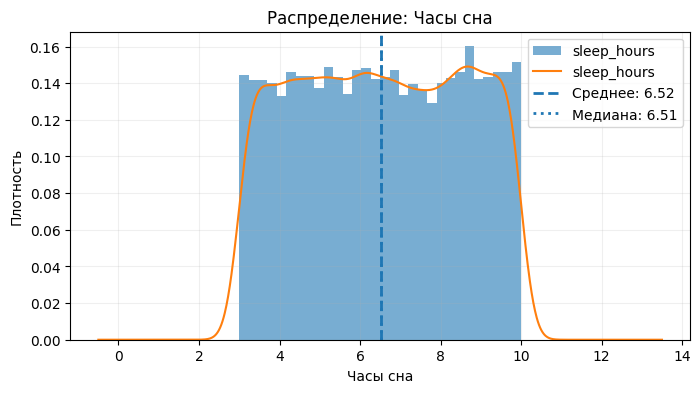

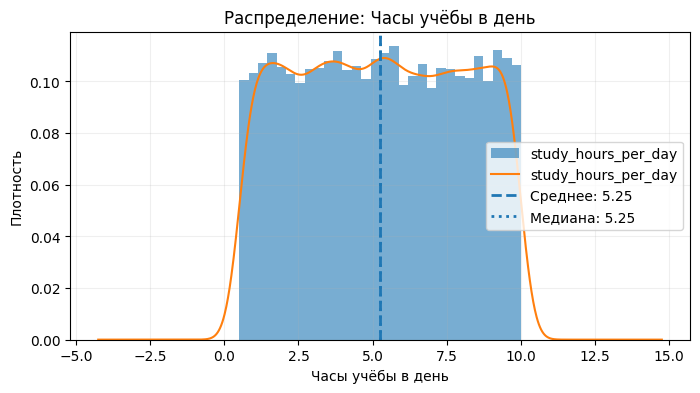

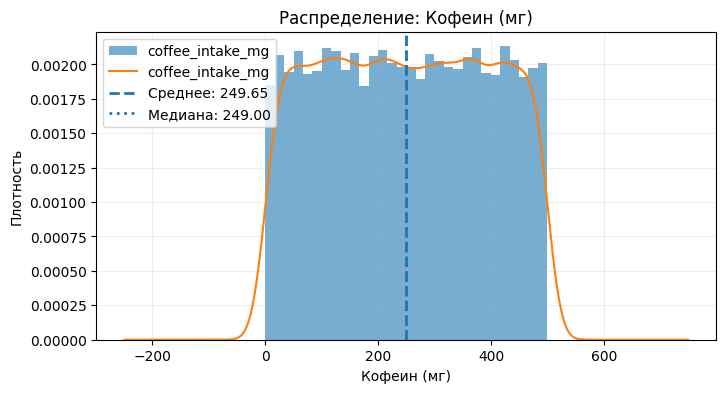

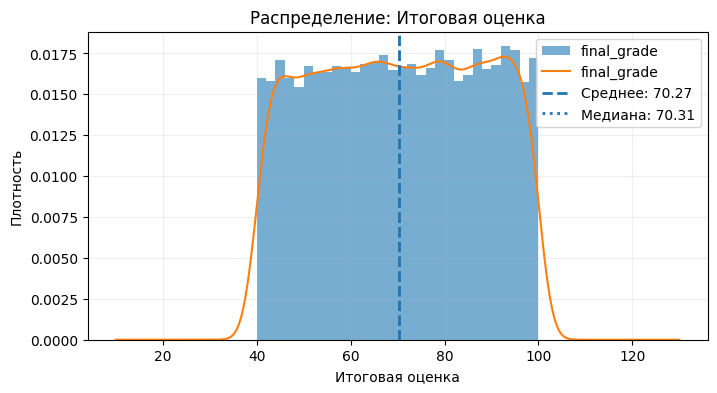

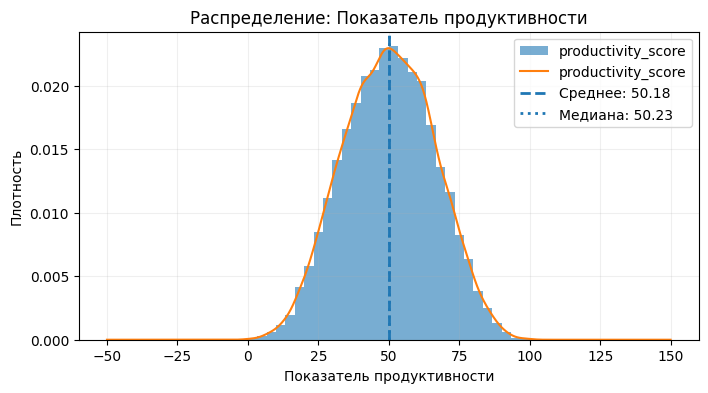

In [ ]:
import matplotlib.pyplot as plt

# Какие колонки строим
cols = [
    "sleep_hours",
    "study_hours_per_day",
    "coffee_intake_mg",
    "final_grade",
    "productivity_score"
]

# Русские названия для подписей
ru = {
    "sleep_hours": "Часы сна",
    "study_hours_per_day": "Часы учёбы в день",
    "coffee_intake_mg": "Кофеин (мг)",
    "final_grade": "Итоговая оценка",
    "productivity_score": "Показатель продуктивности"
}

for col in cols:
    mean_val = df[col].mean()
    median_val = df[col].median()

    plt.figure(figsize=(8, 4))

    # Гистограмма (плотность)
    df[col].plot(kind="hist", bins=30, density=True, alpha=0.6)

    # KDE (плавная оценка плотности)
    df[col].plot(kind="kde")

    # Линии среднего и медианы
    plt.axvline(mean_val, linestyle="--", linewidth=2, label=f"Среднее: {mean_val:.2f}")
    plt.axvline(median_val, linestyle=":", linewidth=2, label=f"Медиана: {median_val:.2f}")

    plt.title(f"Распределение: {ru.get(col, col)}")
    plt.xlabel(ru.get(col, col))
    plt.ylabel("Плотность")
    plt.legend()
    plt.grid(True, alpha=0.2)

    plt.show()

По результатам построения гистограмм с KDE средние значения практически совпадают с медианами. Это свидетельствует об отсутствии выраженной асимметрии и симметричности распределений анализируемых переменных.

Далее рисуем график Boxplot для сравнения распределений.

<Figure size 600x400 with 0 Axes>

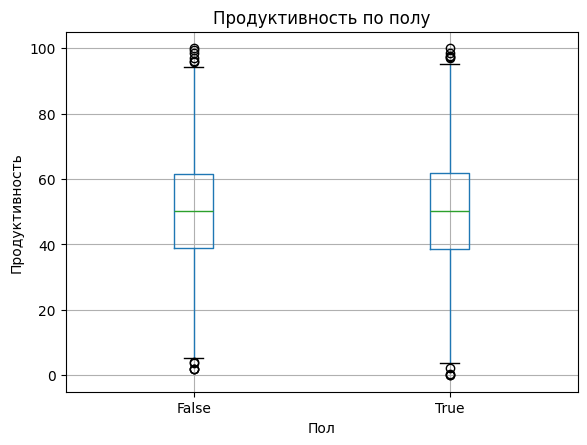

In [ ]:
plt.figure(figsize=(6,4))
df.boxplot(column="productivity_score", by="gender")
plt.title("Продуктивность по полу")
plt.suptitle("")
plt.xlabel("Пол")
plt.ylabel("Продуктивность")
plt.show()

Существенных различий в распределении продуктивности между группами не обнаружено. Однако в обеих группах наблюдаются выбросы, представленные экстремальными значениями показателя продуктивности.

Нарисуем тепловую карту карреляций.

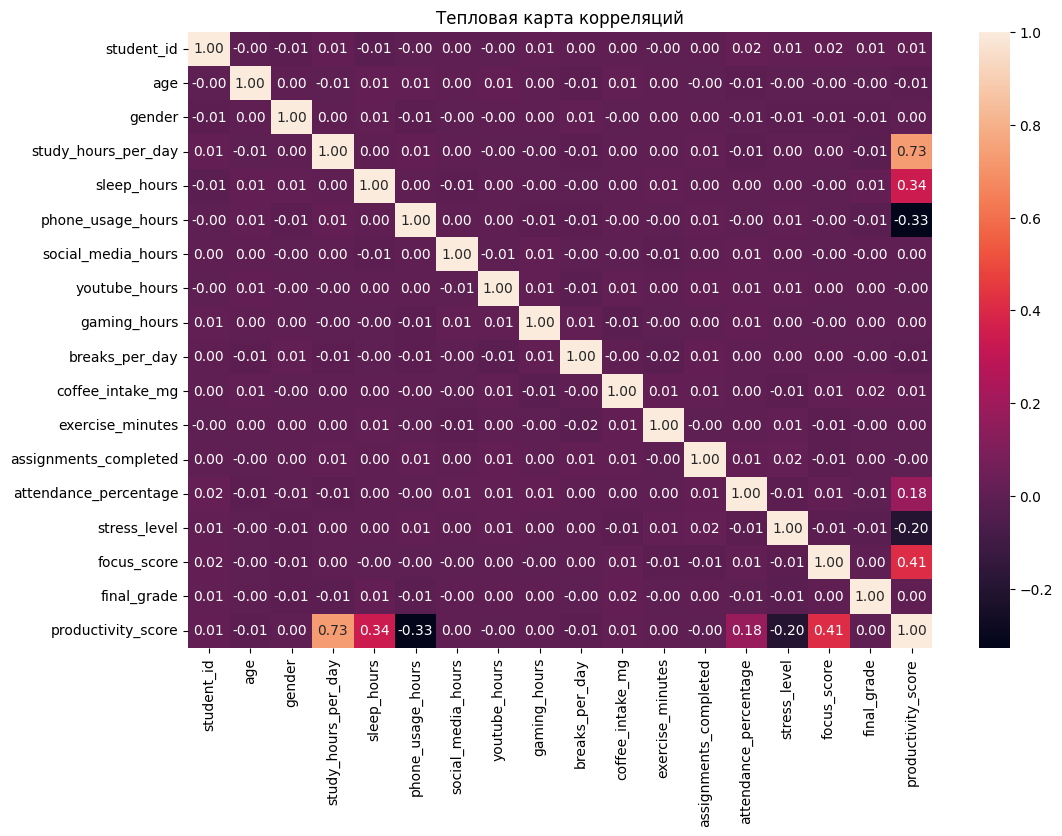

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Берём только числовые переменные
numeric_df = df.select_dtypes(include=["int64", "float64", "bool"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")

plt.title("Тепловая карта корреляций")
plt.show()

Наиболее сильная связь обнаружена между временем учёбы и продуктивностью (r ≈ 0.73), что логично с точки зрения предметной области. Остальные переменные демонстрируют слабые или умеренные корреляции, а большинство признаков практически не связаны линейно между собой.

Выводим диаграмму рассеяния для двух коррелирующих переменных.


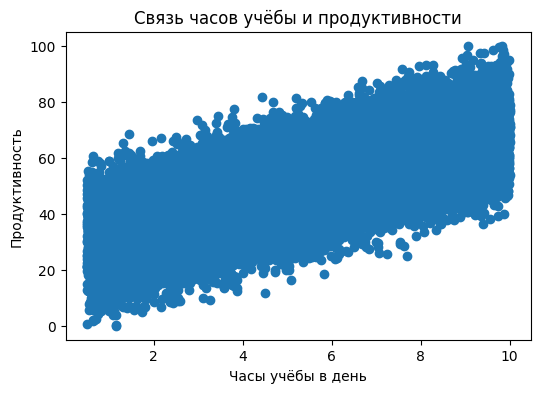

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(df["study_hours_per_day"], df["productivity_score"])

plt.title("Связь часов учёбы и продуктивности")
plt.xlabel("Часы учёбы в день")
plt.ylabel("Продуктивность")

plt.show()

Диаграмма рассеяния демонстрирует выраженную положительную зависимость между количеством часов учёбы и уровнем продуктивности. При увеличении времени учёбы наблюдается рост продуктивности.

Так же выведем Столбчатую диаграмму средних значений по категориям, которая как меняется средняя продуктивность при разном уровне учёбы

<Axes: xlabel='study_level', ylabel='productivity_score'>

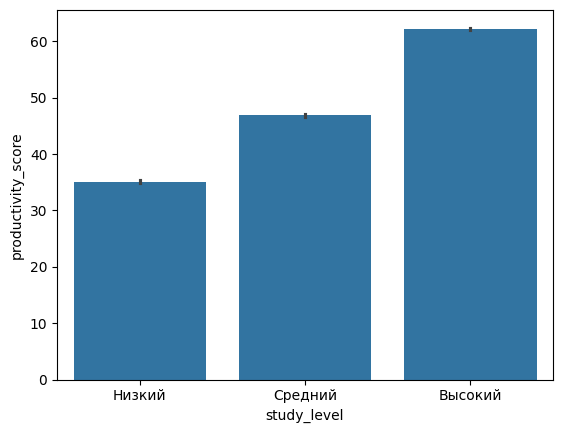

In [ ]:
df["study_level"] = pd.cut(df["study_hours_per_day"],
                           bins=[0,3,6,10],
                           labels=["Низкий", "Средний", "Высокий"])

sns.barplot(x="study_level", y="productivity_score", data=df)

Столбчатая диаграмма демонстрирует рост средней продуктивности при увеличении уровня учебной нагрузки. Это подтверждает наличие положительной зависимости между временем учёбы и продуктивностью.

# Вывод по первичному анализу.

В рамках работы был проведён комплексный разведочный анализ (EDA) датасета, содержащего информацию о поведенческих и учебных характеристиках студентов. Датасет включает 20 000 наблюдений и 18 переменных, отражающих демографические показатели, учебную активность, образ жизни и итоговые показатели эффективности. Пропущенные значения отсутствуют, что свидетельствует о корректности исходных данных и позволяет проводить анализ без дополнительной очистки.
Проведённый разведочный анализ позволил выявить ключевые закономерности в поведении студентов и определить основные факторы, влияющие на уровень их продуктивности. Полученные результаты являются логически обоснованными и соответствуют ожиданиям предметной области. Датасет демонстрирует достаточную информативность и подходит для дальнейшего применения методов машинного обучения с целью прогнозирования показателя продуктивности.